In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

## Problema 6: Partícula en Caja Tridimensional

La ecuación de Schrödinger independiente del tiempo en una caja cúbica $[0,L]^3$:
$$-\frac{\hbar^2}{2m}\nabla^2\psi = E\,\psi, \quad \psi=0 \text{ en los bordes}$$

**Función de onda** (separación de variables):
$$\psi_{lnp}(x,y,z) = \sqrt{\frac{8}{L^3}}\sin\!\left(\frac{l\pi x}{L}\right)\sin\!\left(\frac{n\pi y}{L}\right)\sin\!\left(\frac{p\pi z}{L}\right)$$

**Niveles de energía:**
$$E_{lnp} = \frac{\pi^2\hbar^2}{2mL^2}(l^2 + n^2 + p^2) \equiv \varepsilon_0\,(l^2+n^2+p^2), \quad l,n,p = 1,2,3,\ldots$$

donde $\varepsilon_0 = \pi^2\hbar^2/(2mL^2)$ es la energía fundamental.

### Degeneración:
El nivel $E = \varepsilon_0\cdot K$ tiene degeneración $g = $ número de soluciones enteras positivas de $l^2+n^2+p^2=K$.

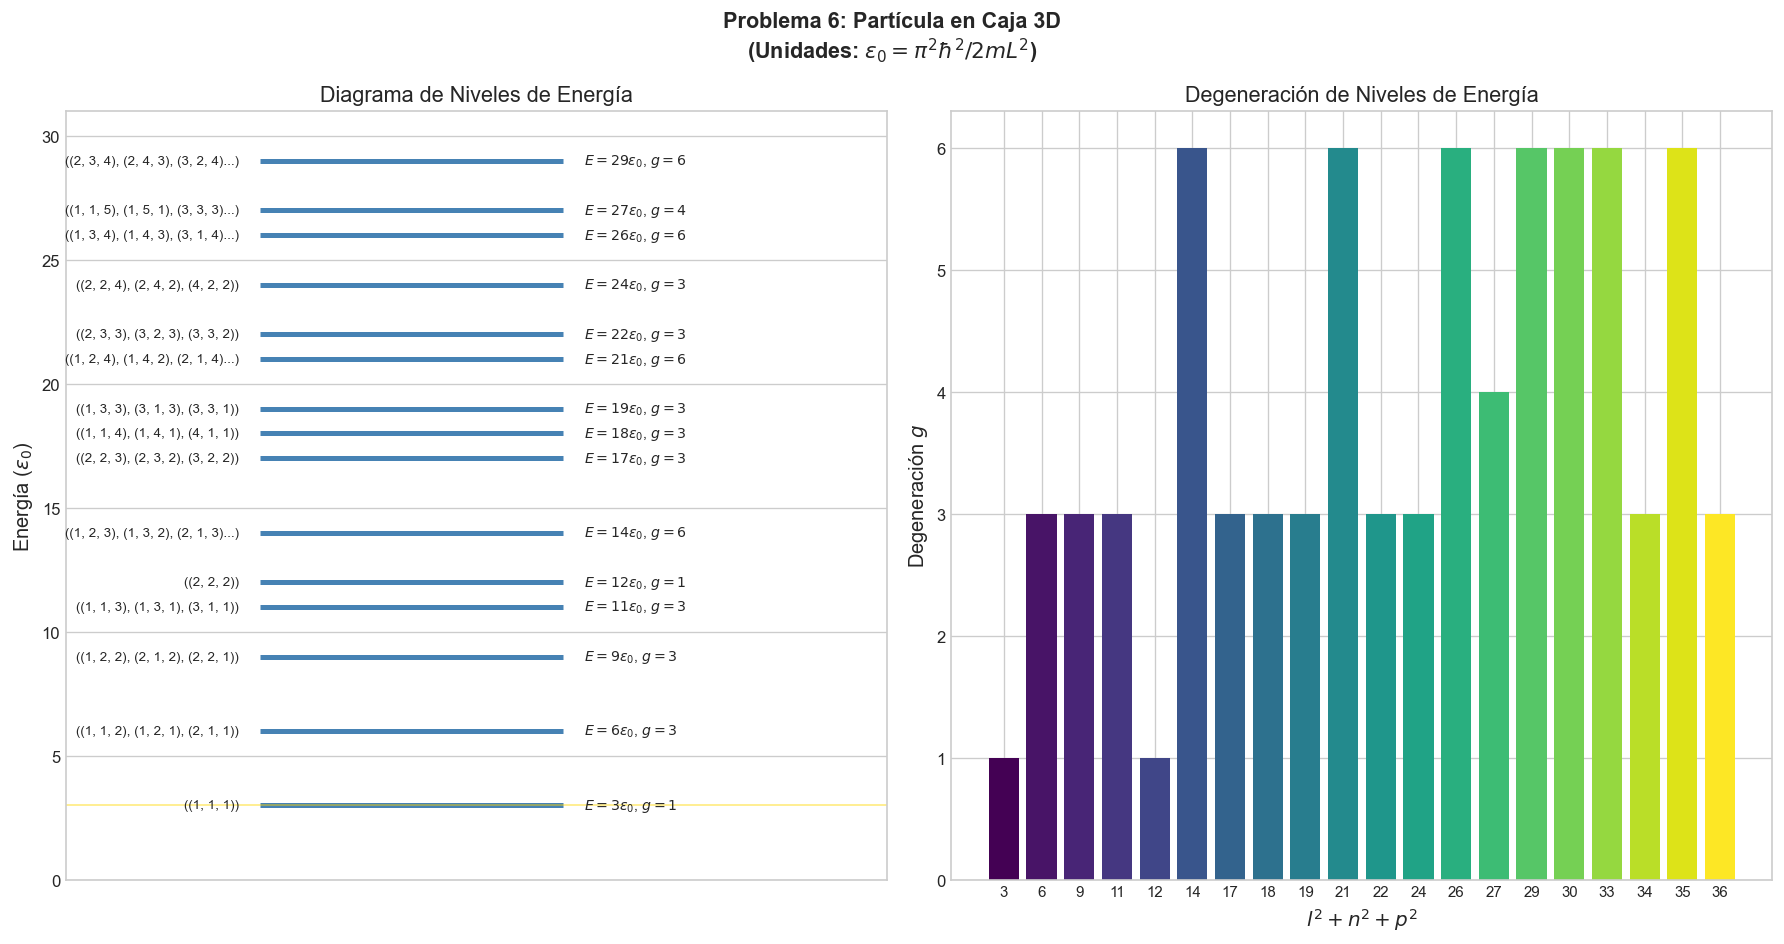

In [4]:
# Partícula en caja 3D — Niveles de energía
levels6 = {}
for l in range(1, 8):
    for n in range(1, 8):
        for p in range(1, 8):
            E = l**2 + n**2 + p**2
            levels6.setdefault(E, []).append((l, n, p))

sorted_E6 = sorted(levels6.keys())[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Problema 6: Partícula en Caja 3D\n'
             '(Unidades: $\\varepsilon_0 = \\pi^2\\hbar^2/2mL^2$)', fontsize=13, fontweight='bold')

# Diagrama de niveles
ax = axes[0]
for E in sorted_E6[:15]:
    deg = len(levels6[E])
    ax.hlines(E, 0.15, 0.85, colors='steelblue', linewidths=3)
    ax.text(0.90, E, f'$E={E}\\varepsilon_0$, $g={deg}$', va='center', fontsize=8.5)
    qns_str = ', '.join([str(q) for q in levels6[E][:3]])
    if len(levels6[E]) > 3:
        qns_str += '...'
    ax.text(0.10, E, f'({qns_str})', va='center', fontsize=8, ha='right')
ax.set_xlim(-0.3, 1.6)
ax.set_ylim(0, sorted_E6[14]+2)
ax.set_ylabel('Energía ($\\varepsilon_0$)')
ax.set_title('Diagrama de Niveles de Energía')
ax.set_xticks([])
ax.axhline(sorted_E6[0], color='gold', linewidth=1, alpha=0.5)

# Degeneración como función del nivel
degs6 = [len(levels6[E]) for E in sorted_E6]
axes[1].bar(range(len(sorted_E6)), degs6, color=plt.cm.viridis(np.linspace(0,1,len(sorted_E6))))
axes[1].set_xticks(range(len(sorted_E6)))
axes[1].set_xticklabels([str(E) for E in sorted_E6], fontsize=9)
axes[1].set_xlabel('$l^2+n^2+p^2$')
axes[1].set_ylabel('Degeneración $g$')
axes[1].set_title('Degeneración de Niveles de Energía')

plt.tight_layout()
plt.show()

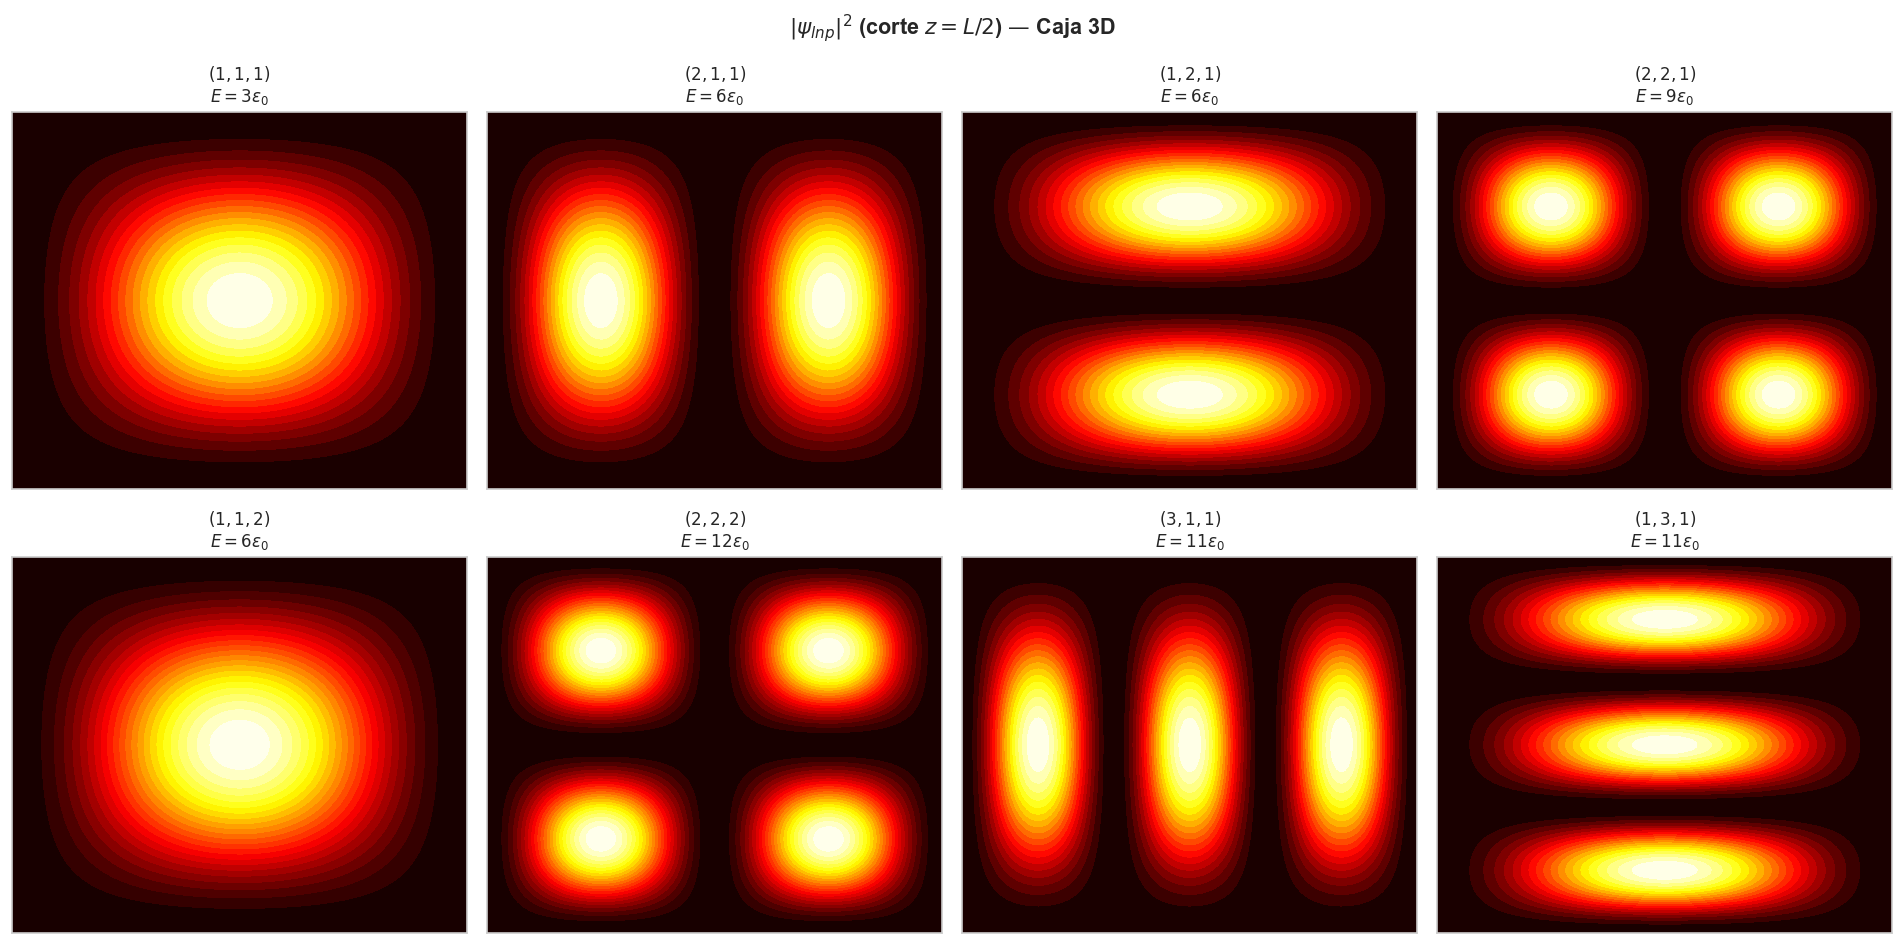

In [5]:
# Densidad de probabilidad |ψ|² para cortes z=L/2
L6 = 1.0
x6 = np.linspace(0, L6, 120)
y6 = np.linspace(0, L6, 120)
X6, Y6 = np.meshgrid(x6, y6)
z_mid = L6/2.0

selected = [(1,1,1),(2,1,1),(1,2,1),(2,2,1),(1,1,2),(2,2,2),(3,1,1),(1,3,1)]

fig = plt.figure(figsize=(16, 8))
fig.suptitle('$|\\psi_{lnp}|^2$ (corte $z=L/2$) — Caja 3D', fontsize=13, fontweight='bold')

for idx, (l, n, p) in enumerate(selected):
    ax = fig.add_subplot(2, 4, idx+1)
    psi2 = (np.sin(l*np.pi*X6/L6)*np.sin(n*np.pi*Y6/L6)*np.sin(p*np.pi*z_mid/L6))**2
    psi2 *= 8/L6**3
    ax.contourf(X6, Y6, psi2, levels=25, cmap='hot')
    E6 = l**2 + n**2 + p**2
    ax.set_title(f'$({l},{n},{p})$\n$E={E6}\\varepsilon_0$', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

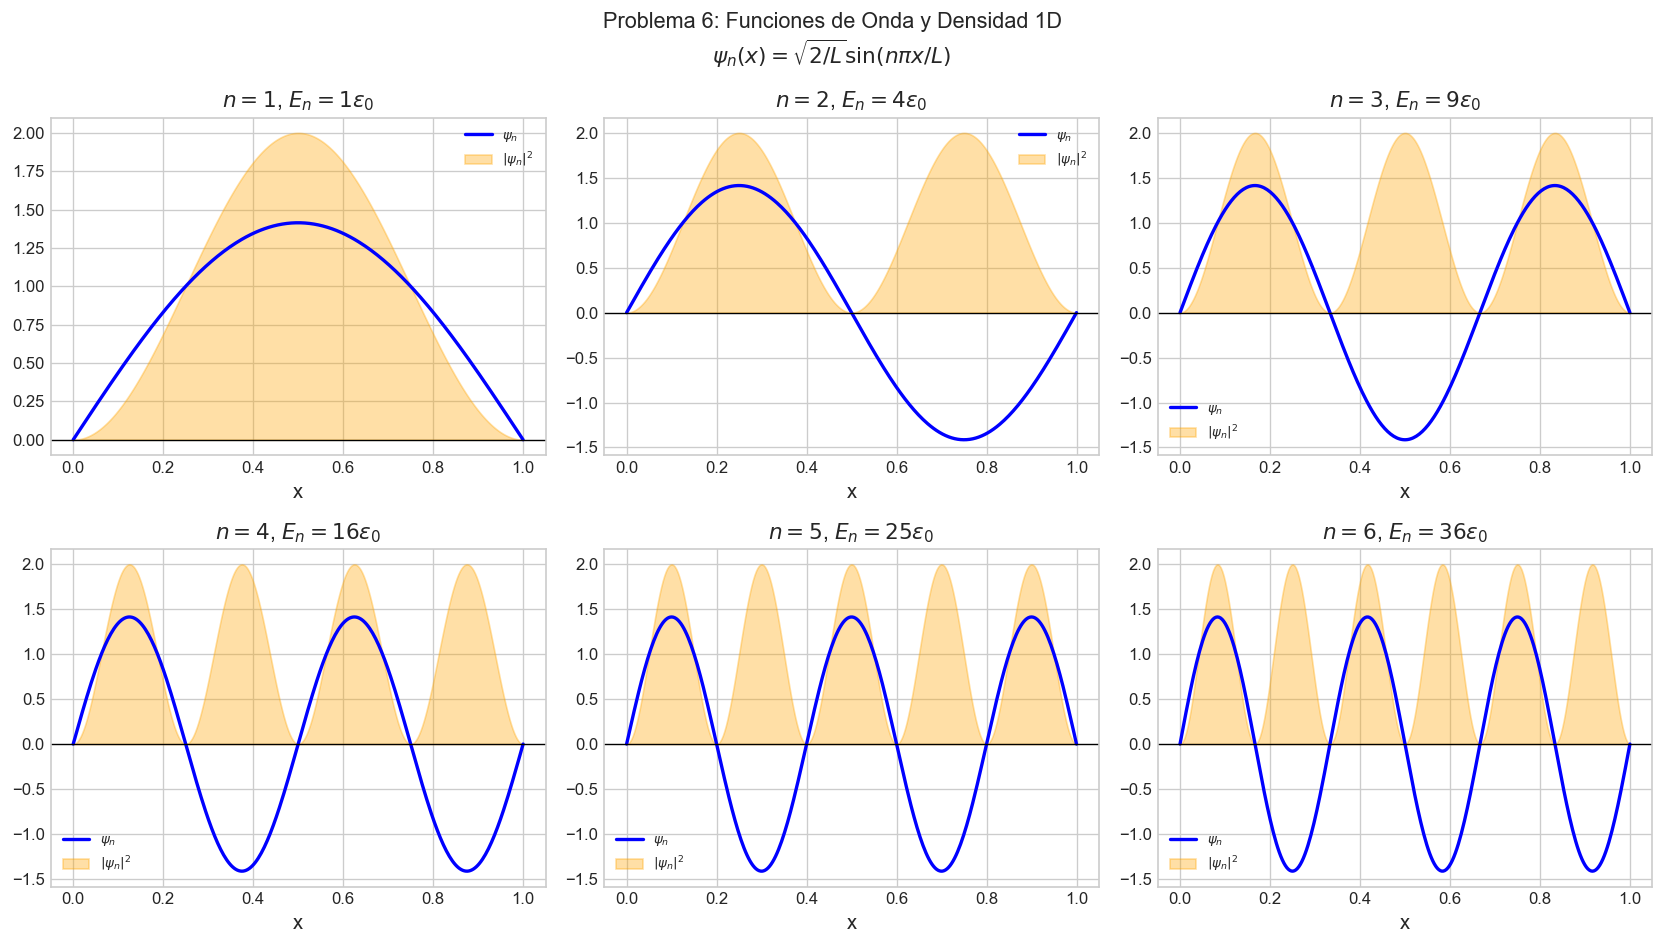

In [6]:
# Funciones de onda 1D y combinaciones
x6_1d = np.linspace(0, L6, 300)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Problema 6: Funciones de Onda y Densidad 1D\n'
             '$\\psi_n(x) = \\sqrt{2/L}\\sin(n\\pi x/L)$', fontsize=13)

for n in range(1, 7):
    row, col = (n-1)//3, (n-1)%3
    psi_n = np.sqrt(2/L6) * np.sin(n*np.pi*x6_1d/L6)
    axes[row,col].plot(x6_1d, psi_n, 'b-', linewidth=2, label='$\\psi_n$')
    axes[row,col].fill_between(x6_1d, psi_n**2, alpha=0.35, color='orange', label='$|\\psi_n|^2$')
    axes[row,col].set_title(f'$n={n}$, $E_n = {n**2}\\varepsilon_0$')
    axes[row,col].set_xlabel('x'); axes[row,col].legend(fontsize=8)
    axes[row,col].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()